## IPL Match Data Analysis | Python, Pandas, MySQL, Matplotlib

#### • Built an end-to-end data analysis pipeline by cleaning and transforming raw IPL match data (1000+ records)  
#### • Performed exploratory data analysis to identify trends across seasons, teams, and match outcomes  
#### • Analyzed toss impact and found that toss outcome has negligible effect (~50%), but decision-making significantly influences results  
#### • Discovered that teams choosing to field first win more matches (~53%), with ~64% teams preferring to chase  
#### • Computed team performance metrics using win percentage, identifying Chennai Super Kings and Mumbai Indians as most consistent teams  
#### • Visualized key insights using bar and pie charts to communicate trends effectively  

## Problem Statement ->
#### Analyze IPL match data to understand:
#### - Toss impact on match results
#### - Team strategies (bat vs field)
#### - Team performance and consistency

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data :

In [2]:
df = pd.read_csv("C:\\Users\\KIIT\\OneDrive\\Desktop\\cleaned_matches.csv")
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,BF Bowden,K Hariharan


## Data Cleaning

In [3]:
df = df.drop(columns=["super_over", "method"], errors="ignore")
df = df.dropna(subset=["season", "team1", "team2"])

df["season"] = df["season"].astype(str).str.split("/").str[0]
df["season"] = pd.to_numeric(df["season"], errors="coerce")

df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y", errors="coerce")
df = df.dropna(subset=["season"])

## Matches per Season

(1095, 18)
0    2008
1    2008
2    2008
3    2008
4    2008
Name: season, dtype: int64
0


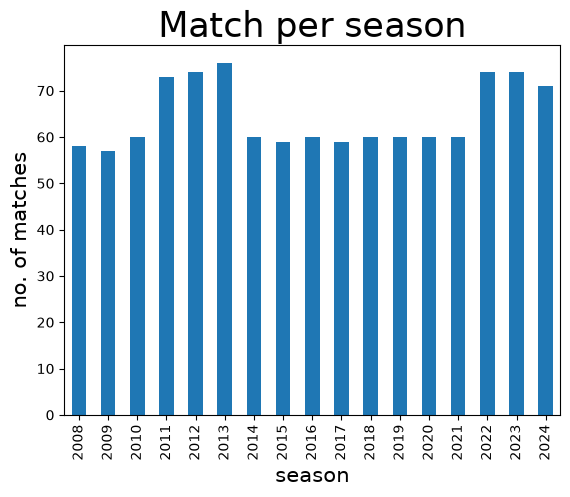

In [4]:
matches_per_season = df.groupby("season").size()
print(df.shape)
print(df["season"].head())
print(df["season"].isna().sum())
matches_per_season.plot(kind="bar")
plt.xlabel("season",fontsize=15)
plt.ylabel("no. of matches",fontsize=15)
plt.title("Match per season",fontsize=25)
plt.show()

#### Insight : Season 2013 had the highest matches. IPL shows growth and later stabilization.

## Toss Decision : 

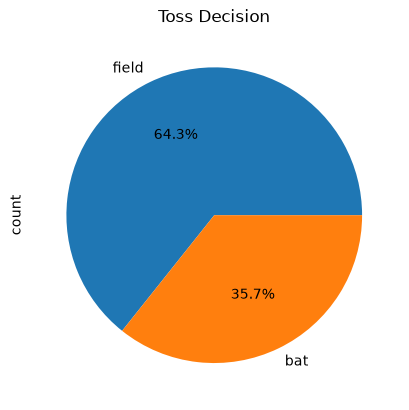

In [5]:
toss = df["toss_decision"].value_counts()

toss.plot(kind="pie", autopct="%1.1f%%")
plt.title("Toss Decision")
plt.show()

#### Insight : ~64% teams choose to field first → strong preference for chasing.

## Toss Impact : 

In [6]:
toss_win = len(df[df["toss_winner"] == df["winner"]])
total = len(df)

print((toss_win / total) * 100)

50.593607305936075


#### Insight : Toss win rate ≈ 50% → negligible impact.

## Bat vs Field Impact : Fielding first has higher success (~53%) than batting first (~45%).

## Team Performance : 

In [7]:
wins = df["winner"].value_counts()
matches = df["team1"].value_counts() + df["team2"].value_counts()

win_percentage = (wins / matches) * 100
win_percentage = win_percentage.sort_values(ascending=False)

## Final Insight : - Toss itself does not impact results
### - Decision after toss is critical
### - Teams prefer chasing and it works
### - CSK and MI are most consistent teams